In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import folium
from branca.colormap import linear
from branca.colormap import LinearColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
import warnings
from scipy import stats
from folium.plugins import HeatMap
import matplotlib.cm as cm
import matplotlib.colors as colors
from cartopy.util import add_cyclic_point  # For plotting maps
import hydroeval as he
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_ind
from scipy.stats import linregress

In [2]:
#Define a function that calculates various metrics of comparison between modelled and observed data
def abline(slope, intercept, ax, **kwargs):
    """Plot a line from slope and intercept"""
    x_vals = np.array(ax.get_xlim())
    y_vals = intercept + slope * x_vals
    ax.plot(x_vals, y_vals, **kwargs)
def round_to_nearest_day(td):
    total_days = td.total_seconds() / (24 * 3600)
    rounded_days = int(np.round(total_days))
    return rounded_days
    
def calculate_model_eval(group):
    # Extract X and y
    X = group['Modelled'].values.reshape(-1, 1)  # Reshape to ensure X is a 2D array
    y = group['Observed'].values

    # Fit linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Calculate R-squared value
    r2 = model.score(X, y)

    # Calculate correlation coefficient R
    corr_matrix = np.corrcoef(X.flatten(), y)
    r = corr_matrix[0, 1]

    # Get predictions
    y_pred = model.predict(X)

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y, y_pred))

    # Calculate normalized RMSE
    nrmse = rmse / (np.max(y) - np.min(y))

    # Get slope and intercept
    slope = model.coef_[0]
    intercept = model.intercept_

    # Count number of values
    num_values = len(y)

    return pd.Series({
        'Num_Values': num_values, 
        'R': r, 
        'R2': r2, 
        'RMSE': rmse, 
        'NRMSE': nrmse, 
        'Slope': slope, 
        'Intercept': intercept
    })
    
#Define some other model metrics
def calculate_site_solute_metrics(data):
    # Create an empty DataFrame to store the results
    results_df = pd.DataFrame()

    # Iterate over unique combinations of siteId and Solute
    for (site, var), group in data.groupby(['siteId', 'Variable']):
        # Extract Modelled and Observed data for the current site and solute
        simulations = group['Modelled'].tolist()
        evaluations = group['Observed'].tolist()

        # Calculate NSE and KGE metrics
        nse = he.evaluator(he.nse, simulations, evaluations)
        kge, r, alpha, beta = he.evaluator(he.kge, simulations, evaluations)

        # Create a DataFrame with the results for the current site and solute
        result = pd.DataFrame({
            'siteId': [site],
            'Variable': [var],
            'NSE': [nse[0]],  # Extracting the scalar value from the array
            'KGE': [kge[0]],  # Extracting the scalar value from the array
            #'R': [r],
            #'Alpha': [alpha],
            #'Beta': [beta]
        })

        # Append the result to the results DataFrame
        results_df = pd.concat([results_df, result], ignore_index=True)

    return results_df

def run_statistics(df, df_name):
    # Count the number of unique sites
    site_count = df.groupby(['Variable'])['siteId'].nunique()
    print(f"Unique site count for {df_name}:\n", site_count)
    
    # For each variable, count the number of observations
    obs_count = df.groupby(['Variable'])['Modelled'].count()
    print(f"\nObservation count for {df_name}:\n", obs_count)
    
    # For each variable and site, count the number of observations and then average
    obs_site_count = df.groupby(['Variable', 'siteId'])['Modelled'].count().mean()
    print(f"\nAverage number of observations per site for {df_name}:\n", obs_site_count)

def calculate_cohens_d(modelled, observed):
    # Calculate the mean difference
    mean_diff = np.mean(modelled) - np.mean(observed)
    
    # Calculate the pooled standard deviation
    pooled_std = np.sqrt(((np.std(modelled, ddof=1) ** 2 + np.std(observed, ddof=1) ** 2) / 2))
    
    # Calculate Cohen's d
    cohens_d = mean_diff / pooled_std
    
    return cohens_d

def interpret_cohens_d(d):
    if d < 0.2:
        return "Small effect"
    elif 0.2 <= d < 0.8:
        return "Medium effect"
    else:
        return "Large effect"

In [3]:
#Read in merged df for model validation calculations (inorganics from NADP and DOC/BC from external data sources)
pathData = '/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/'
os.chdir(pathData)
nadp_df = pd.read_csv('MUSICA_PREC_SO4_NO3_NH4_Timeseries.SamplingInt_Summed_pairedNADPsites.csv', parse_dates = ['dateOn', 'dateOff', 'dateOnround', 'dateOffround'])

#1. Remove rows where there is no observed rain but the model is predicting rain and calculate percent error in precip
nadp_df = nadp_df.loc[nadp_df.ppt_mm != 0,]
nadp_df['Precip_Perc_Error'] = ((abs(nadp_df['PREC_tot_mm'] - nadp_df['ppt_mm']))/(nadp_df['PREC_tot_mm']))*100
nadp_df = nadp_df.dropna(subset = 'Precip_Perc_Error')
nadp_df

,Unnamed: 0,siteId,SamplingInt,lat,lon,PREC_tot_mm,Mod_SO4_mgm2,Mod_NH4_mgm2,Mod_NO3_mgm2,dateOn,...,Year,ppt_mm,SO4_mgm2,NH4_mgm2,NO3_mgm2,dateOnround,dateOffround,IntTime,IntDays,Precip_Perc_Error
0,0,AB32,10.0,50.639425,248.354064,2.829707,0.842824,0.058601,1.002034,2017-01-17 20:27:00,...,2017,0.508,0.785876,0.139192,1.197356,2017-01-18,2017-01-25,6 days 22:33:00,7,82.047612
1,1,AB32,11.0,50.639425,248.354064,4.100366,1.657402,0.052795,3.229616,2017-02-14 19:50:00,...,2017,6.576,2.380512,1.032432,5.050368,2017-02-15,2017-02-23,7 days 21:40:00,8,60.375932
2,2,AB32,12.0,50.639425,248.354064,3.618132,3.162410,0.026281,1.508876,2017-02-22 17:30:00,...,2017,0.892,1.471800,0.142720,3.207632,2017-02-23,2017-03-01,6 days 02:35:00,6,75.346397
3,3,AB32,13.0,50.639425,248.354064,3.467163,2.262975,0.222969,4.239472,2017-02-28 20:05:00,...,2017,0.484,1.436996,0.353804,1.677060,2017-03-01,2017-03-07,5 days 23:25:00,6,86.040462
4,4,AB32,14.0,50.639425,248.354064,5.438491,1.786078,0.139512,1.770456,2017-03-13 17:30:00,...,2017,1.778,4.482338,0.218694,3.195066,2017-03-14,2017-03-22,8 days 01:10:00,8,67.307109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17447,17447,WY99,86.0,43.925168,255.847662,39.194686,7.428019,2.674603,26.997486,2018-08-14 16:00:00,...,2018,12.954,6.800850,10.415016,9.961626,2018-08-15,2018-08-22,7 days 00:02:00,7,66.949602
17448,17448,WY99,87.0,43.925168,255.847662,12.697556,4.654752,3.783942,16.442955,2018-09-18 16:15:00,...,2018,5.334,2.672334,3.296412,5.515356,2018-09-19,2018-09-26,7 days 00:18:00,7,57.991915
17449,17449,WY99,88.0,43.925168,255.847662,15.564126,4.424000,0.955052,11.043850,2018-09-25 16:33:00,...,2018,14.732,5.671820,3.859784,6.835648,2018-09-26,2018-10-04,7 days 23:03:00,8,5.346436
17450,17450,WY99,89.0,43.925168,255.847662,27.036335,6.065336,5.006215,19.781492,2018-10-03 15:36:00,...,2018,10.754,3.570328,4.215568,7.129902,2018-10-04,2018-10-11,7 days 03:59:00,7,60.223899


In [4]:
#Initial data cleaning for org_df (organics)
org_df = pd.read_csv('MUSICA_PREC_DOC_Timeseries.SamplingInt_Summed_pairedNADPsites.csv', parse_dates = ['dateOnround', 'dateOffround'])
org_df = org_df.rename(columns = {'Precip_mm' : 'ppt_mm'})

#1. Remove rows where there is no observed rain but the model is predicting rain and calculate percent error in precip
org_df = org_df.loc[org_df.ppt_mm != 0,]
org_df['Precip_Perc_Error'] = ((abs(org_df['PREC_tot_mm'] - org_df['ppt_mm']))/(org_df['PREC_tot_mm']))*100
org_df = org_df.dropna(subset = 'Precip_Perc_Error')

#3. Remove rows where the IntTime variable is greater than 0 days and less than 31 days
org_df['IntTime'] = pd.to_timedelta(org_df['IntTime'])
org_df['IntDays'] = org_df['IntTime'].apply(round_to_nearest_day)
org_df = org_df.loc[((org_df['IntDays'] > 0) & (org_df['IntDays'] <= 31)),]

#5. Subset DOC data and format relevant columns
org_df = org_df[['siteId', 'latitude', 'longitude', 'lon', 'dateOnround', 'dateOffround', 'IntDays', 'SamplingInt',
                      'Precip_Perc_Error', 'PREC_tot_mm', 'Mod_DOC_mgm2', 
                      'ppt_mm', 'DOC_mgm2']]
org_df = org_df.rename(columns = {'latitude':'lat'})
org_df

,siteId,lat,longitude,lon,dateOnround,dateOffround,IntDays,SamplingInt,Precip_Perc_Error,PREC_tot_mm,Mod_DOC_mgm2,ppt_mm,DOC_mgm2
0,AK02,58.5139,-134.7843,234.706634,2017-02-22,2017-03-01,7,0.0,188.851301,2.813905,0.143684,8.128,3.16992
1,AK02,58.5139,-134.7843,234.706634,2017-03-22,2017-03-29,7,1.0,1035.271582,1.073928,0.162358,12.192,5.97408
2,AK02,58.5139,-134.7843,234.706634,2017-04-19,2017-04-26,7,2.0,4778.900551,0.166595,0.039837,8.128,4.79552
3,AK02,58.5139,-134.7843,234.706634,2017-05-17,2017-05-24,7,3.0,1077.855657,3.320950,0.154209,39.116,18.77568
4,AK02,58.5139,-134.7843,234.706634,2017-06-14,2017-06-21,7,4.0,19843.664561,0.396086,0.003325,78.994,33.96742
...,...,...,...,...,...,...,...,...,...,...,...,...,...
346,WY08,44.9166,-110.4203,249.623190,2018-06-13,2018-06-19,6,7.0,32.213480,61.077040,10.120379,41.402,24.42718
347,WY08,44.9166,-110.4203,249.623190,2018-08-22,2018-08-29,7,8.0,3.739203,14.690685,11.867891,15.240,21.79320
348,WY08,44.9166,-110.4203,249.623190,2018-10-03,2018-10-10,7,9.0,33.662865,20.293309,2.063477,13.462,10.09650
349,WY08,44.9166,-110.4203,249.623190,2018-11-22,2018-11-27,5,10.0,19.168298,7.673182,0.610313,9.144,3.74904


In [5]:
#Create individual dataframes for dropping nans (eg no chemistry was recorded for observed data) 

################# Inorganics
SO4_df = nadp_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'lat', 'lon', 'Mod_SO4_mgm2', 'SO4_mgm2']].dropna()
SO4_df['Variable'] = 'WetDep_SO4_mgm2'
SO4_df = SO4_df.rename(columns = {'Mod_SO4_mgm2':'Modelled', 'SO4_mgm2' : 'Observed'})

NO3_df = nadp_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'lat', 'lon', 'Mod_NO3_mgm2', 'NO3_mgm2']].dropna()
NO3_df['Variable'] = 'WetDep_NO3_mgm2'
NO3_df = NO3_df.rename(columns = {'Mod_NO3_mgm2':'Modelled', 'NO3_mgm2' : 'Observed'})

NH4_df = nadp_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'lat', 'lon', 'Mod_NH4_mgm2', 'NH4_mgm2']].dropna()
NH4_df['Variable'] = 'WetDep_NH4_mgm2'
NH4_df = NH4_df.rename(columns = {'Mod_NH4_mgm2':'Modelled', 'NH4_mgm2' : 'Observed'})

############### Organics
DOC_df_all = org_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'lat', 'lon', 'Mod_DOC_mgm2', 'DOC_mgm2']].dropna()
DOC_df_all['Variable'] = 'WetDep_DOC_mgm2'
DOC_df_all = DOC_df_all.rename(columns = {'Mod_DOC_mgm2':'Modelled', 'DOC_mgm2' : 'Observed'})

#Final df creation
mod_nadp_chem = pd.concat([SO4_df, NO3_df, NH4_df, DOC_df_all])
mod_nadp_chem

,siteId,SamplingInt,dateOnround,dateOffround,lat,lon,Modelled,Observed,Variable
0,AB32,10.0,2017-01-18,2017-01-25,50.639425,248.354064,0.842824,0.785876,WetDep_SO4_mgm2
1,AB32,11.0,2017-02-15,2017-02-23,50.639425,248.354064,1.657402,2.380512,WetDep_SO4_mgm2
2,AB32,12.0,2017-02-23,2017-03-01,50.639425,248.354064,3.162410,1.471800,WetDep_SO4_mgm2
3,AB32,13.0,2017-03-01,2017-03-07,50.639425,248.354064,2.262975,1.436996,WetDep_SO4_mgm2
4,AB32,14.0,2017-03-14,2017-03-22,50.639425,248.354064,1.786078,4.482338,WetDep_SO4_mgm2
...,...,...,...,...,...,...,...,...,...
346,WY08,7.0,2018-06-13,2018-06-19,44.916600,249.623190,10.120379,24.427180,WetDep_DOC_mgm2
347,WY08,8.0,2018-08-22,2018-08-29,44.916600,249.623190,11.867891,21.793200,WetDep_DOC_mgm2
348,WY08,9.0,2018-10-03,2018-10-10,44.916600,249.623190,2.063477,10.096500,WetDep_DOC_mgm2
349,WY08,10.0,2018-11-22,2018-11-27,44.916600,249.623190,0.610313,3.749040,WetDep_DOC_mgm2


In [6]:
#Add precip to this clean chem dataframe

#Precipitation_inorganics
ppt_df_inorg = nadp_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'lat', 'lon', 'PREC_tot_mm', 'ppt_mm']]
ppt_df_inorg = ppt_df_inorg.rename(columns = {'PREC_tot_mm':'Modelled_precip', 'ppt_mm' : 'Observed_precip'})

#Precipitation organics
ppt_df_org = org_df[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'lat', 'lon', 'PREC_tot_mm', 'ppt_mm']]
ppt_df_org = ppt_df_org.rename(columns = {'PREC_tot_mm':'Modelled_precip', 'ppt_mm' : 'Observed_precip'})

#Need precip as its own variable in mod_nadp_clean
ppt_df = pd.concat([ppt_df_org, ppt_df_inorg]).drop_duplicates()
ppt_df['Variable'] = 'Precipitation_mm'
ppt_df = ppt_df.rename(columns = {'Modelled_precip':'Modelled', 'Observed_precip' : 'Observed'})
mod_nadp_clean = pd.concat([mod_nadp_chem, ppt_df])
mod_nadp_clean

,siteId,SamplingInt,dateOnround,dateOffround,lat,lon,Modelled,Observed,Variable
0,AB32,10.0,2017-01-18,2017-01-25,50.639425,248.354064,0.842824,0.785876,WetDep_SO4_mgm2
1,AB32,11.0,2017-02-15,2017-02-23,50.639425,248.354064,1.657402,2.380512,WetDep_SO4_mgm2
2,AB32,12.0,2017-02-23,2017-03-01,50.639425,248.354064,3.162410,1.471800,WetDep_SO4_mgm2
3,AB32,13.0,2017-03-01,2017-03-07,50.639425,248.354064,2.262975,1.436996,WetDep_SO4_mgm2
4,AB32,14.0,2017-03-14,2017-03-22,50.639425,248.354064,1.786078,4.482338,WetDep_SO4_mgm2
...,...,...,...,...,...,...,...,...,...
17447,WY99,86.0,2018-08-15,2018-08-22,43.925168,255.847662,39.194686,12.954000,Precipitation_mm
17448,WY99,87.0,2018-09-19,2018-09-26,43.925168,255.847662,12.697556,5.334000,Precipitation_mm
17449,WY99,88.0,2018-09-26,2018-10-04,43.925168,255.847662,15.564126,14.732000,Precipitation_mm
17450,WY99,89.0,2018-10-04,2018-10-11,43.925168,255.847662,27.036335,10.754000,Precipitation_mm


In [7]:
#Calculcate precip % error
mod_nadp_clean['Percent_Error'] = ((abs(mod_nadp_clean['Modelled'] - mod_nadp_clean['Observed']))/(mod_nadp_clean['Modelled']))*100
mod_nadp_clean.dropna(inplace = True)
#mod_nadp_clean

#Assigning precip percent error to all values in df
ppt_qual = pd.concat([ppt_df_org, ppt_df_inorg]).drop_duplicates()
ppt_qual['Precip_Percent_Error'] = ((abs(ppt_qual['Modelled_precip'] - ppt_qual['Observed_precip']))/(ppt_qual['Modelled_precip']))*100
ppt_qual = ppt_qual[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'lat', 'lon', 'Precip_Percent_Error']]

#Merge with mod_nadp_clean
mod_nadp_clean = pd.merge(mod_nadp_clean, ppt_qual, on = ['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'lat', 'lon'])
mod_nadp_clean

,siteId,SamplingInt,dateOnround,dateOffround,lat,lon,Modelled,Observed,Variable,Percent_Error,Precip_Percent_Error
0,AB32,10.0,2017-01-18,2017-01-25,50.639425,248.354064,0.842824,0.785876,WetDep_SO4_mgm2,6.756779,82.047612
1,AB32,10.0,2017-01-18,2017-01-25,50.639425,248.354064,1.002034,1.197356,WetDep_NO3_mgm2,19.492532,82.047612
2,AB32,10.0,2017-01-18,2017-01-25,50.639425,248.354064,0.058601,0.139192,WetDep_NH4_mgm2,137.525635,82.047612
3,AB32,10.0,2017-01-18,2017-01-25,50.639425,248.354064,2.829707,0.508000,Precipitation_mm,82.047612,82.047612
4,AB32,11.0,2017-02-15,2017-02-23,50.639425,248.354064,1.657402,2.380512,WetDep_SO4_mgm2,43.629116,60.375932
...,...,...,...,...,...,...,...,...,...,...,...
70414,CO01,60.0,2018-06-13,2018-06-21,38.078048,256.633104,9.283300,0.254000,Precipitation_mm,97.263904,97.263904
70415,IL46,81.0,2018-03-06,2018-03-14,38.897243,270.388918,6.318682,5.842000,Precipitation_mm,7.544008,7.544008
70416,SK31,59.0,2018-07-18,2018-07-25,58.175119,250.538318,32.015981,4.064000,Precipitation_mm,87.306339,87.306339
70417,WA21,58.0,2018-05-30,2018-06-06,46.845071,237.666732,7.463475,1.270000,Precipitation_mm,82.983797,82.983797


/glade/derecho/scratch/demurray/tmp/ipykernel_52878/3154380656.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean_test['Variable'] = pd.Categorical(mod_nadp_clean_test['Variable'], categories=desired_order, ordered=True)


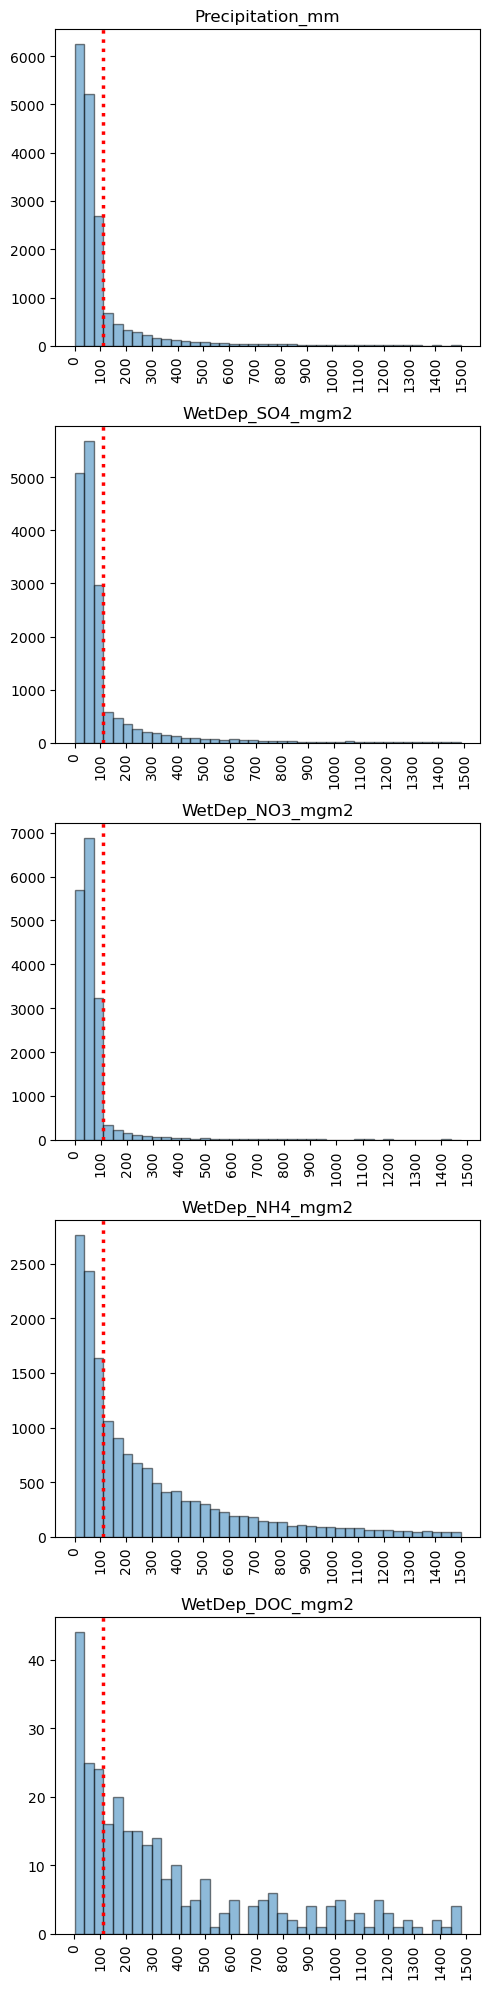

Variable
Precipitation_mm    2.298608e+11
WetDep_DOC_mgm2     1.226614e+06
WetDep_NH4_mgm2     3.341185e+18
WetDep_NO3_mgm2     6.026286e+08
WetDep_SO4_mgm2     3.147652e+19
Name: Percent_Error, dtype: float64

In [8]:
# PLOT: histogram of % error

# Filter the data
mod_nadp_clean = mod_nadp_clean.loc[mod_nadp_clean['Percent_Error'] != np.inf,]
mod_nadp_clean_test = mod_nadp_clean.loc[((mod_nadp_clean['Percent_Error'] < 1500) & (mod_nadp_clean['Percent_Error'] > -100)),]
desired_order = ['Precipitation_mm', 'WetDep_SO4_mgm2', 'WetDep_NO3_mgm2', 'WetDep_NH4_mgm2', 'WetDep_DOC_mgm2']

# Convert the 'Variable' column to a categorical type with the specified order
mod_nadp_clean_test['Variable'] = pd.Categorical(mod_nadp_clean_test['Variable'], categories=desired_order, ordered=True)

# Sort the DataFrame based on the new categorical order
mod_nadp_clean_test = mod_nadp_clean_test.sort_values('Variable')

# Get unique variables
variables = mod_nadp_clean_test['Variable'].unique()

# Number of rows and columns for the subplot grid
rows = 5
cols = 1

# Create a figure with subplots
fig, axs = plt.subplots(rows, cols, figsize=(5, 20))
fig.tight_layout(pad=3.0)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Loop through the variables and create a histogram for each
for idx, variable in enumerate(variables):
    df = mod_nadp_clean_test.loc[mod_nadp_clean_test['Variable'] == variable,]
    ax = axs[idx]
    ax.hist(df['Percent_Error'], edgecolor='black', alpha=0.5, bins=40)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(variable)
    ax.set_xticks(np.arange(0, 1501, 100))
    ax.tick_params(axis='x', rotation=90)
    ax.axvline(x=110, color='red', linestyle=':', linewidth=2.5)
# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused subplots
for idx in range(len(mod_nadp_clean_test['Variable'].unique()), rows * cols):
    fig.delaxes(axs[idx])

#plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/MUSICA _ no filter_Percent Error Histogram.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)
plt.show()

#print the max % error for each solute
max_err = mod_nadp_clean.groupby('Variable')['Percent_Error'].max()
max_err

/glade/derecho/scratch/demurray/tmp/ipykernel_52878/2734684079.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean['Month'] = mod_nadp_clean['dateOffround'].dt.month
/glade/derecho/scratch/demurray/tmp/ipykernel_52878/2734684079.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean['Variable'] = pd.Categorical(mod_nadp_clean['Variable'], categories=desired_order, ordered=True)


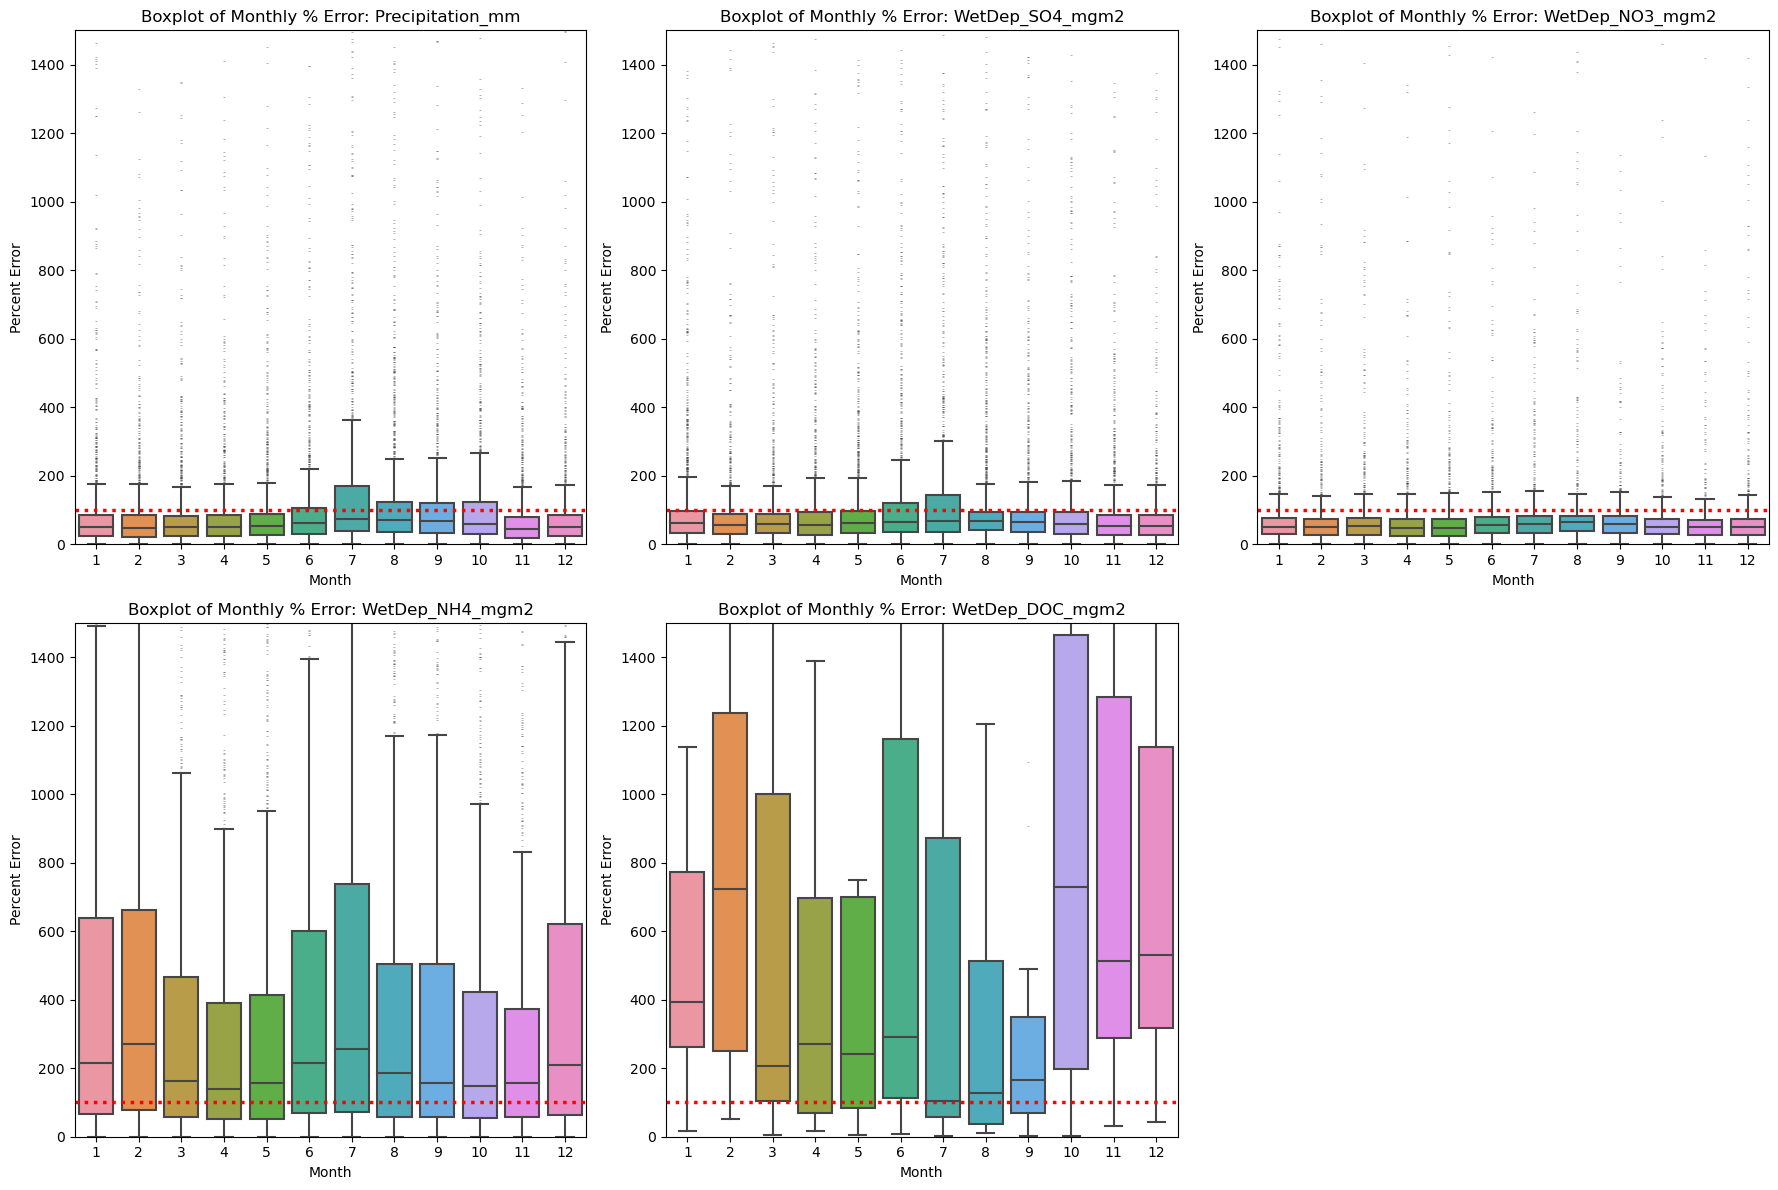

In [9]:
#Plot seasonality of percent error (no filter)
mod_nadp_clean['Month'] = mod_nadp_clean['dateOffround'].dt.month

# Convert the 'Variable' column to a categorical type with the specified order
mod_nadp_clean['Variable'] = pd.Categorical(mod_nadp_clean['Variable'], categories=desired_order, ordered=True)

# Sort the DataFrame based on the new categorical order
mod_nadp_clean= mod_nadp_clean.sort_values('Variable')

# Get unique variables
variables = mod_nadp_clean['Variable'].unique()

# Number of rows and columns for the subplot grid
rows = 2
cols = 3

# Create a figure with subplots
fig, axs = plt.subplots(rows, cols, figsize=(18, 12))
fig.tight_layout(pad=5.0)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Loop through the variables and create a boxplot for each
for idx, variable in enumerate(variables):
    df = mod_nadp_clean.loc[mod_nadp_clean['Variable'] == variable,]
    ax = axs[idx]
    sns.boxplot(data=df, x='Month', y='Percent_Error', ax=ax, fliersize=0.1)
    ax.set_ylabel('Percent Error')
    ax.set_ylim(0, 1500)
    ax.set_title(f'Boxplot of Monthly % Error: {variable}')
    ax.axhline(y=100, color='red', linestyle=':', linewidth=2.5)

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused subplots
for idx in range(len(variables), rows * cols):
    fig.delaxes(axs[idx])
    
#plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/MUSICA No Filter Seasonal Percent Error Boxplot.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)

plt.show()

In [10]:
# Create two filtered dataframes:

#Determined from other analysis (PrecipThresh Model Metrics)--> filter dataframe at 100% precip error tolerance.
mod_nadp_clean_100 = mod_nadp_clean.loc[((mod_nadp_clean['Precip_Percent_Error'] < 100) & (mod_nadp_clean['Precip_Percent_Error'] > -100)),]

#Now filter dataframe at 100% error tolerance between chemistry observations.
mod_nadp_clean_100_chem = mod_nadp_clean_100.loc[((mod_nadp_clean_100['Percent_Error'] < 100) & (mod_nadp_clean_100['Percent_Error'] > -100)),]

#write this to a csv
mod_nadp_clean_100_chem.to_csv('/glade/u/home/demurray/Murray-NCAR-GVP/MUSICA Analyses/Data outputs/MUSICA Cleaned Paired Modeled Observed Timeseries.csv')

In [21]:
#Print some statistics on how each of these dataframes compare to one another (excluding DOC because considerably less data here)
#no_filter = mod_nadp_clean.loc[mod_nadp_clean['Variable'] != 'WetDep_DOC_mgm2',]
#rain_filter = mod_nadp_clean_100.loc[mod_nadp_clean_100['Variable'] != 'WetDep_DOC_mgm2',]
chem_filter = mod_nadp_clean_100_chem.loc[mod_nadp_clean_100_chem['Variable'] != 'WetDep_DOC_mgm2',]

#run_statistics(no_filter, "mod_nadp_clean")
#run_statistics(rain_filter, "mod_nadp_clean_100")
run_statistics(chem_filter, "mod_nadp_clean_100_chem")

Unique site count for mod_nadp_clean_100_chem:
 Variable
Precipitation_mm    268
WetDep_SO4_mgm2     267
WetDep_NO3_mgm2     267
WetDep_NH4_mgm2     261
WetDep_DOC_mgm2       0
Name: siteId, dtype: int64

Observation count for mod_nadp_clean_100_chem:
 Variable
Precipitation_mm    13824
WetDep_SO4_mgm2     11893
WetDep_NO3_mgm2     12935
WetDep_NH4_mgm2      5900
WetDep_DOC_mgm2         0
Name: Modelled, dtype: int64

Average number of observations per site for mod_nadp_clean_100_chem:
 33.24776119402985


/glade/derecho/scratch/demurray/tmp/ipykernel_52878/4147070519.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean_100['Month'] = mod_nadp_clean_100['dateOffround'].dt.month
/glade/derecho/scratch/demurray/tmp/ipykernel_52878/4147070519.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mod_nadp_clean_100['Variable'] = pd.Categorical(mod_nadp_clean_100['Variable'], categories=desired_order, ordered=True)


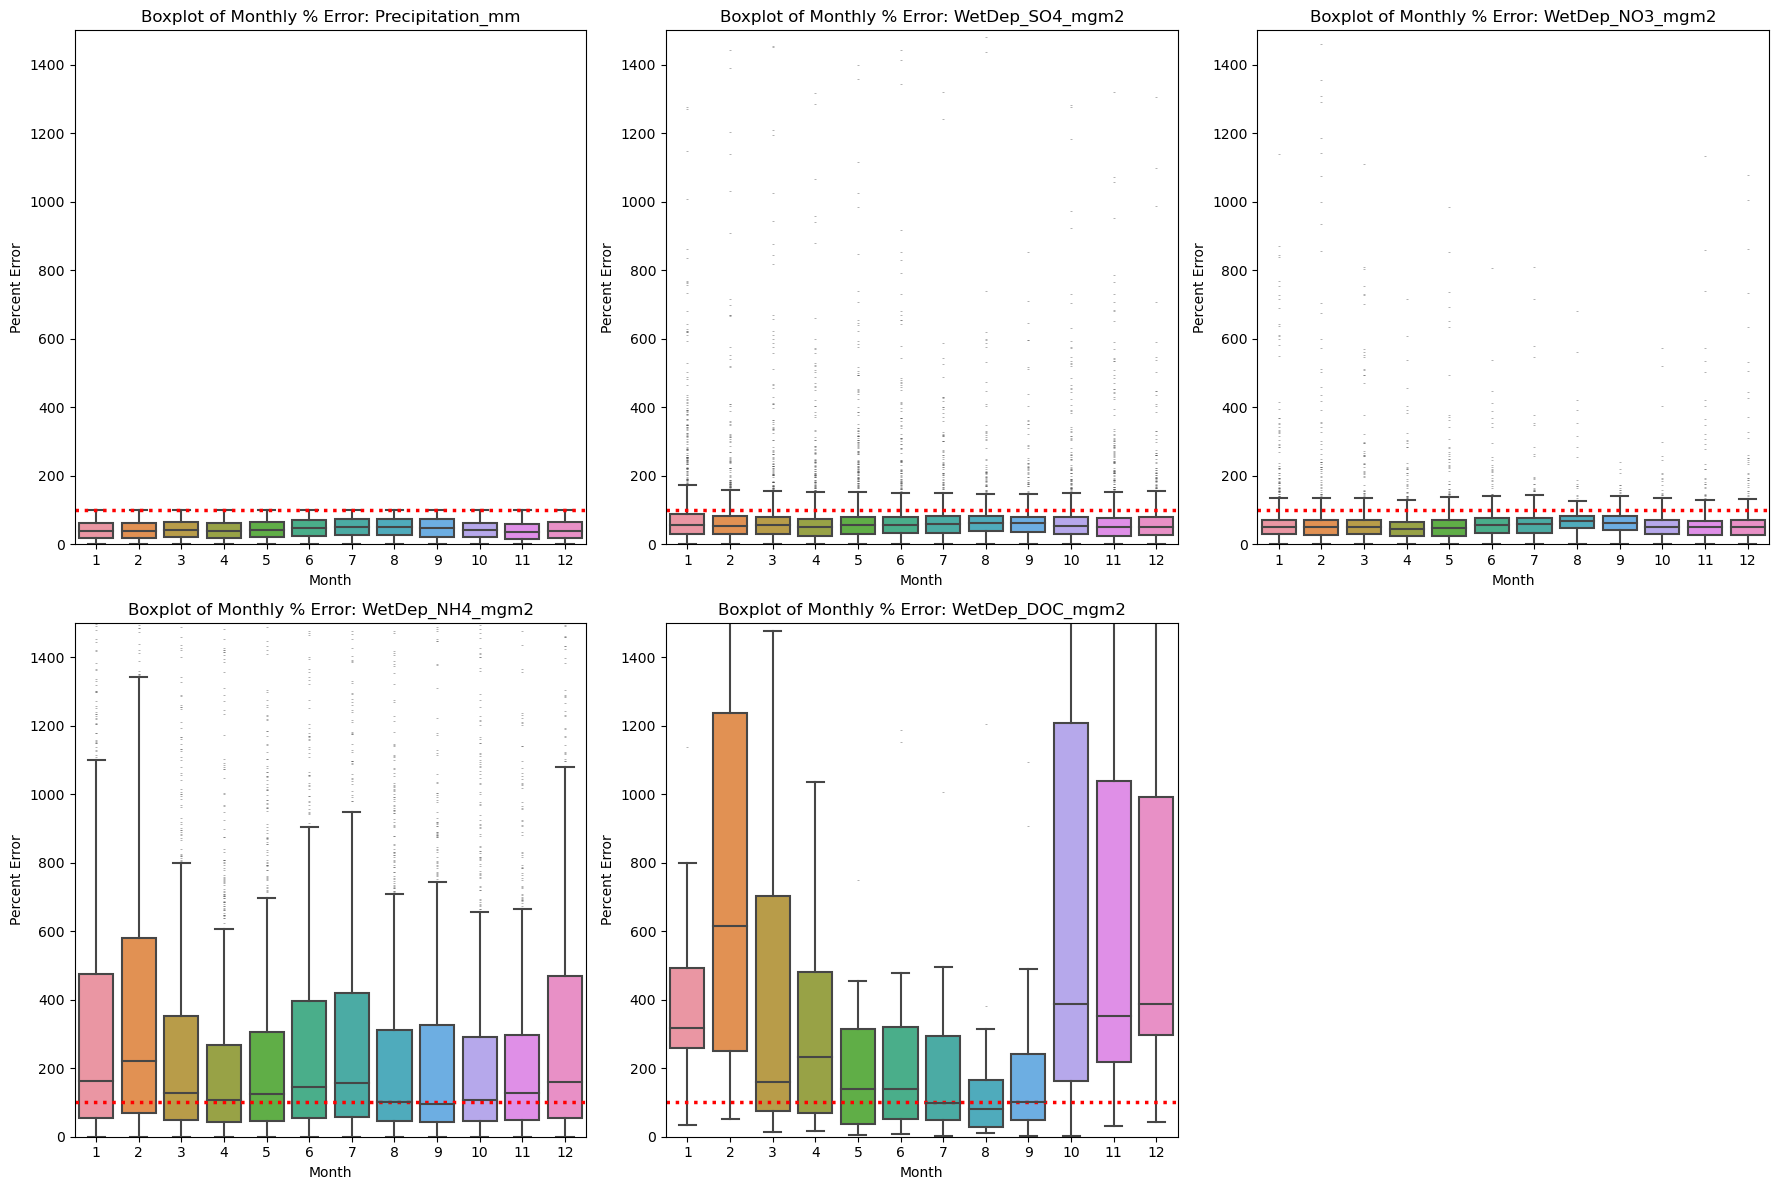

In [12]:
#Plot seasonality of percent error (precip filter)
mod_nadp_clean_100['Month'] = mod_nadp_clean_100['dateOffround'].dt.month

# Convert the 'Variable' column to a categorical type with the specified order
mod_nadp_clean_100['Variable'] = pd.Categorical(mod_nadp_clean_100['Variable'], categories=desired_order, ordered=True)

# Sort the DataFrame based on the new categorical order
mod_nadp_clean_100= mod_nadp_clean_100.sort_values('Variable')

# Get unique variables
variables = mod_nadp_clean_100['Variable'].unique()

# Number of rows and columns for the subplot grid
rows = 2
cols = 3

# Create a figure with subplots
fig, axs = plt.subplots(rows, cols, figsize=(18, 12))
fig.tight_layout(pad=5.0)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Loop through the variables and create a boxplot for each
for idx, variable in enumerate(variables):
    df = mod_nadp_clean_100.loc[mod_nadp_clean_100['Variable'] == variable,]
    ax = axs[idx]
    sns.boxplot(data=df, x='Month', y='Percent_Error', ax=ax, fliersize=0.1)
    ax.set_ylabel('Percent Error')
    ax.set_ylim(0, 1500)
    ax.set_title(f'Boxplot of Monthly % Error: {variable}')
    ax.axhline(y=100, color='red', linestyle=':', linewidth=2.5)

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused subplots
for idx in range(len(variables), rows * cols):
    fig.delaxes(axs[idx])

#plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/MUSICA Precip Filter Seasonal Percent Error Boxplot.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)

plt.show()

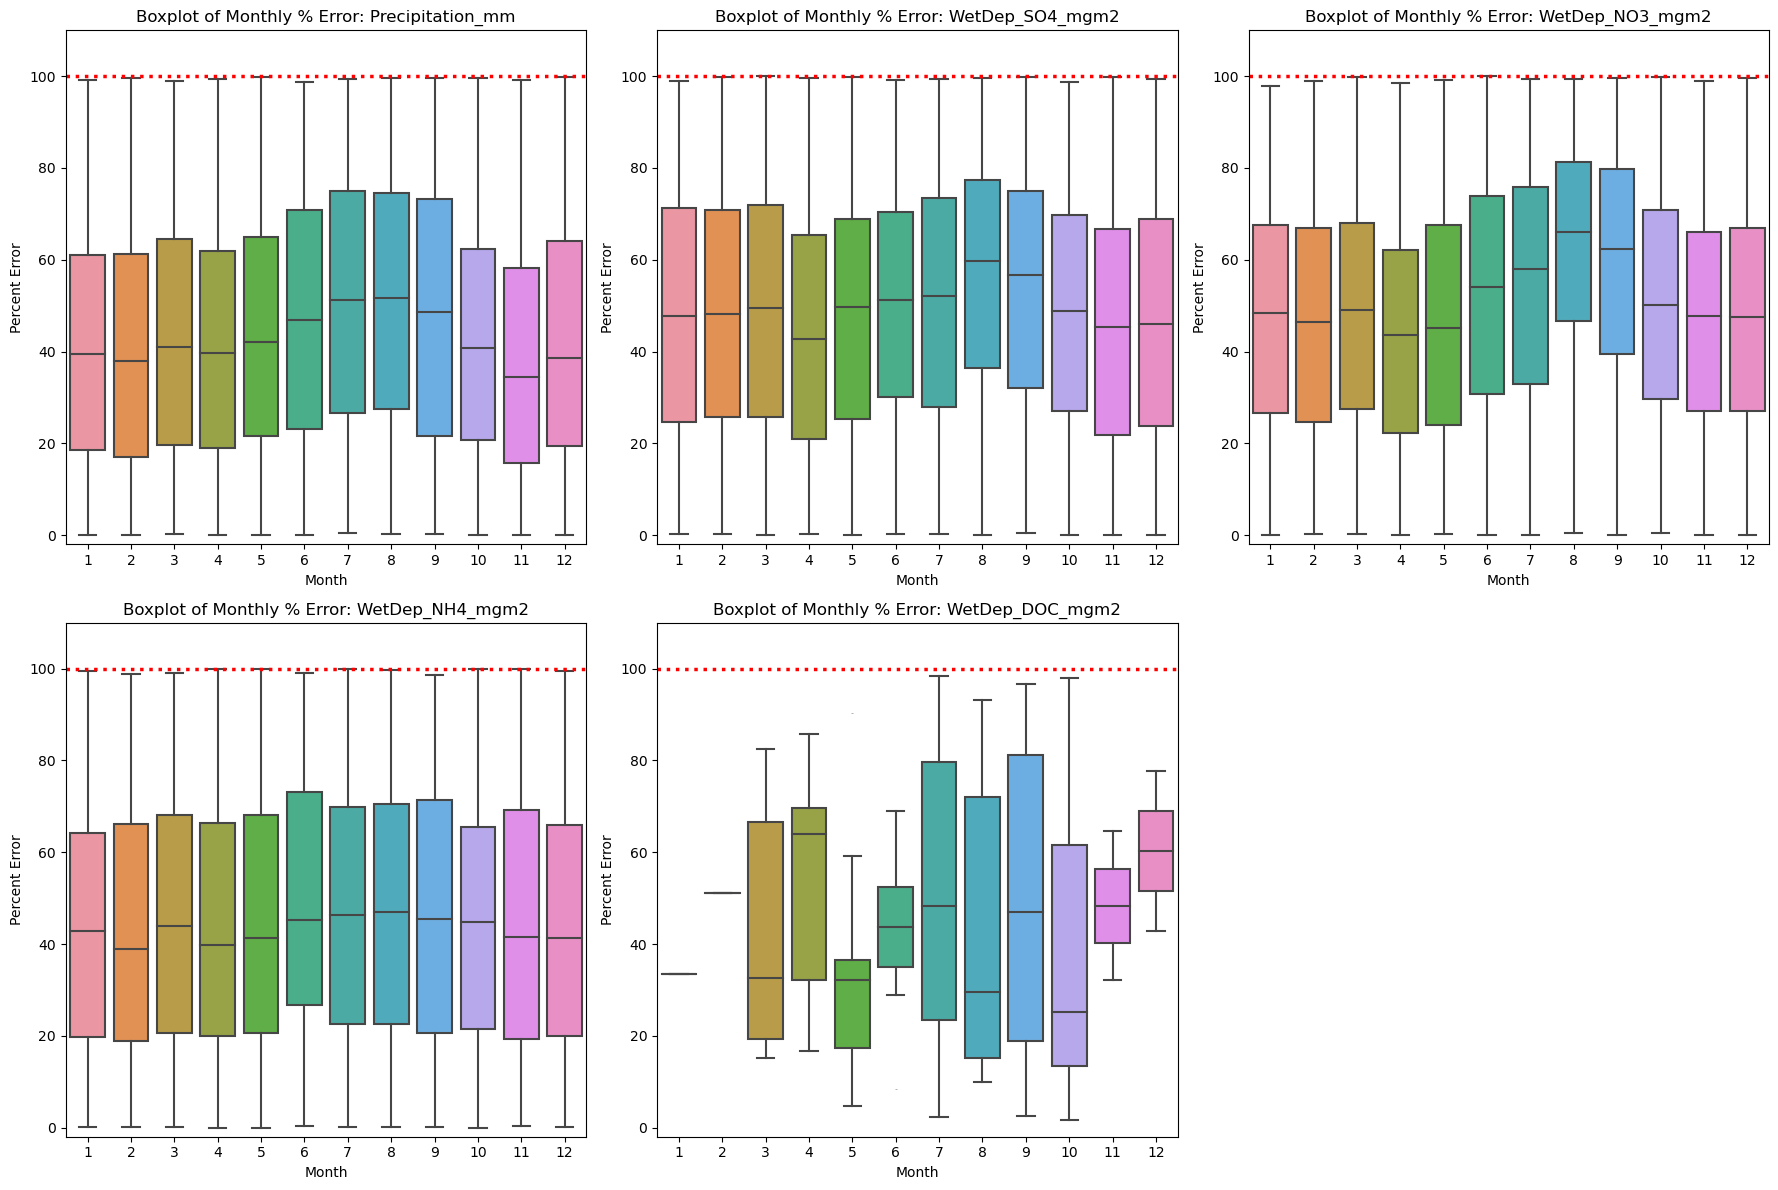

In [13]:
#Plot seasonality of percent error (precip + chem filter)
mod_nadp_clean_100_chem['Month'] = mod_nadp_clean_100_chem['dateOffround'].dt.month

# Convert the 'Variable' column to a categorical type with the specified order
mod_nadp_clean_100_chem['Variable'] = pd.Categorical(mod_nadp_clean_100_chem['Variable'], categories=desired_order, ordered=True)

# Sort the DataFrame based on the new categorical order
mod_nadp_clean_100_chem= mod_nadp_clean_100_chem.sort_values('Variable')

# Get unique variables
variables = mod_nadp_clean_100_chem['Variable'].unique()

# Number of rows and columns for the subplot grid
rows = 2
cols = 3

# Create a figure with subplots
fig, axs = plt.subplots(rows, cols, figsize=(18, 12))
fig.tight_layout(pad=5.0)

# Flatten the axes array for easy iteration
axs = axs.flatten()

# Loop through the variables and create a boxplot for each
for idx, variable in enumerate(variables):
    df = mod_nadp_clean_100_chem.loc[mod_nadp_clean_100_chem['Variable'] == variable,]
    ax = axs[idx]
    sns.boxplot(data=df, x='Month', y='Percent_Error', ax=ax, fliersize=0.1)
    ax.set_ylabel('Percent Error')
    ax.set_ylim(-2, 110)
    ax.set_title(f'Boxplot of Monthly % Error: {variable}')
    ax.axhline(y=100, color='red', linestyle=':', linewidth=2.5)

# Adjust layout to prevent overlap
plt.tight_layout()

# Hide any unused subplots
for idx in range(len(variables), rows * cols):
    fig.delaxes(axs[idx])

#plt.savefig('/glade/u/home/demurray/External File Uploads/Figures/MUSICA Chem + Precip Filter Seasonal Percent Error Boxplot.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)

plt.show()

In [14]:
#GLOBAL RMSE VALUES
glob_modobs = pd.read_csv('/glade/u/home/demurray/Murray-NCAR-GVP/Data outputs/Cleaned Paired Modeled Observed Timeseries.csv')
glob_modobs = glob_modobs.rename(columns = {'Modelled' : 'Modeled_global', 'Observed': 'Observed_global'})
glob_modobs = glob_modobs[['siteId', 'SamplingInt', 'Variable', 'Modeled_global', 'Observed_global']]
mus_glob = pd.merge(mod_nadp_clean_100_chem, glob_modobs, on = ['siteId', 'SamplingInt', 'Variable'], how = 'left')
mus_glob.dropna(inplace = True)
mus_glob = mus_glob[['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'lat', 'lon','Variable',
       'Modelled', 'Observed', 'Modeled_global', 'Observed_global' ]]
mus_glob

,siteId,SamplingInt,dateOnround,dateOffround,lat,lon,Variable,Modelled,Observed,Modeled_global,Observed_global
0,WI36,127.0,2018-12-05,2018-12-12,46.021506,270.329080,Precipitation_mm,0.994502,1.01600,41.772611,9.14400
23,BC24,18.0,2017-08-02,2017-08-09,72.762243,234.706634,Precipitation_mm,7.464334,0.25400,88.579928,99.82200
25,WI08,86.0,2017-11-29,2017-12-06,46.717467,268.384720,Precipitation_mm,9.027433,9.03500,13.529082,20.32000
54,WI08,88.0,2017-12-13,2017-12-20,46.717467,268.384720,Precipitation_mm,5.295343,10.41400,9.966254,9.90600
55,WI08,100.0,2018-04-11,2018-04-18,46.717467,268.384720,Precipitation_mm,40.311264,42.41800,28.205406,17.78000
...,...,...,...,...,...,...,...,...,...,...,...
44640,WY08,8.0,2018-08-22,2018-08-29,44.916600,249.623190,WetDep_DOC_mgm2,11.867891,21.79320,14.817144,21.79320
44641,GA09,6.0,2017-08-09,2017-08-16,30.740400,277.924539,WetDep_DOC_mgm2,33.639863,6.46176,15.782435,6.46176
44643,GA09,9.0,2018-04-04,2018-04-11,30.740400,277.924539,WetDep_DOC_mgm2,11.451418,3.79730,16.191202,3.79730
44645,WV05,13.0,2018-04-04,2018-04-11,38.879400,279.101951,WetDep_DOC_mgm2,7.315821,8.77824,16.254479,8.77824


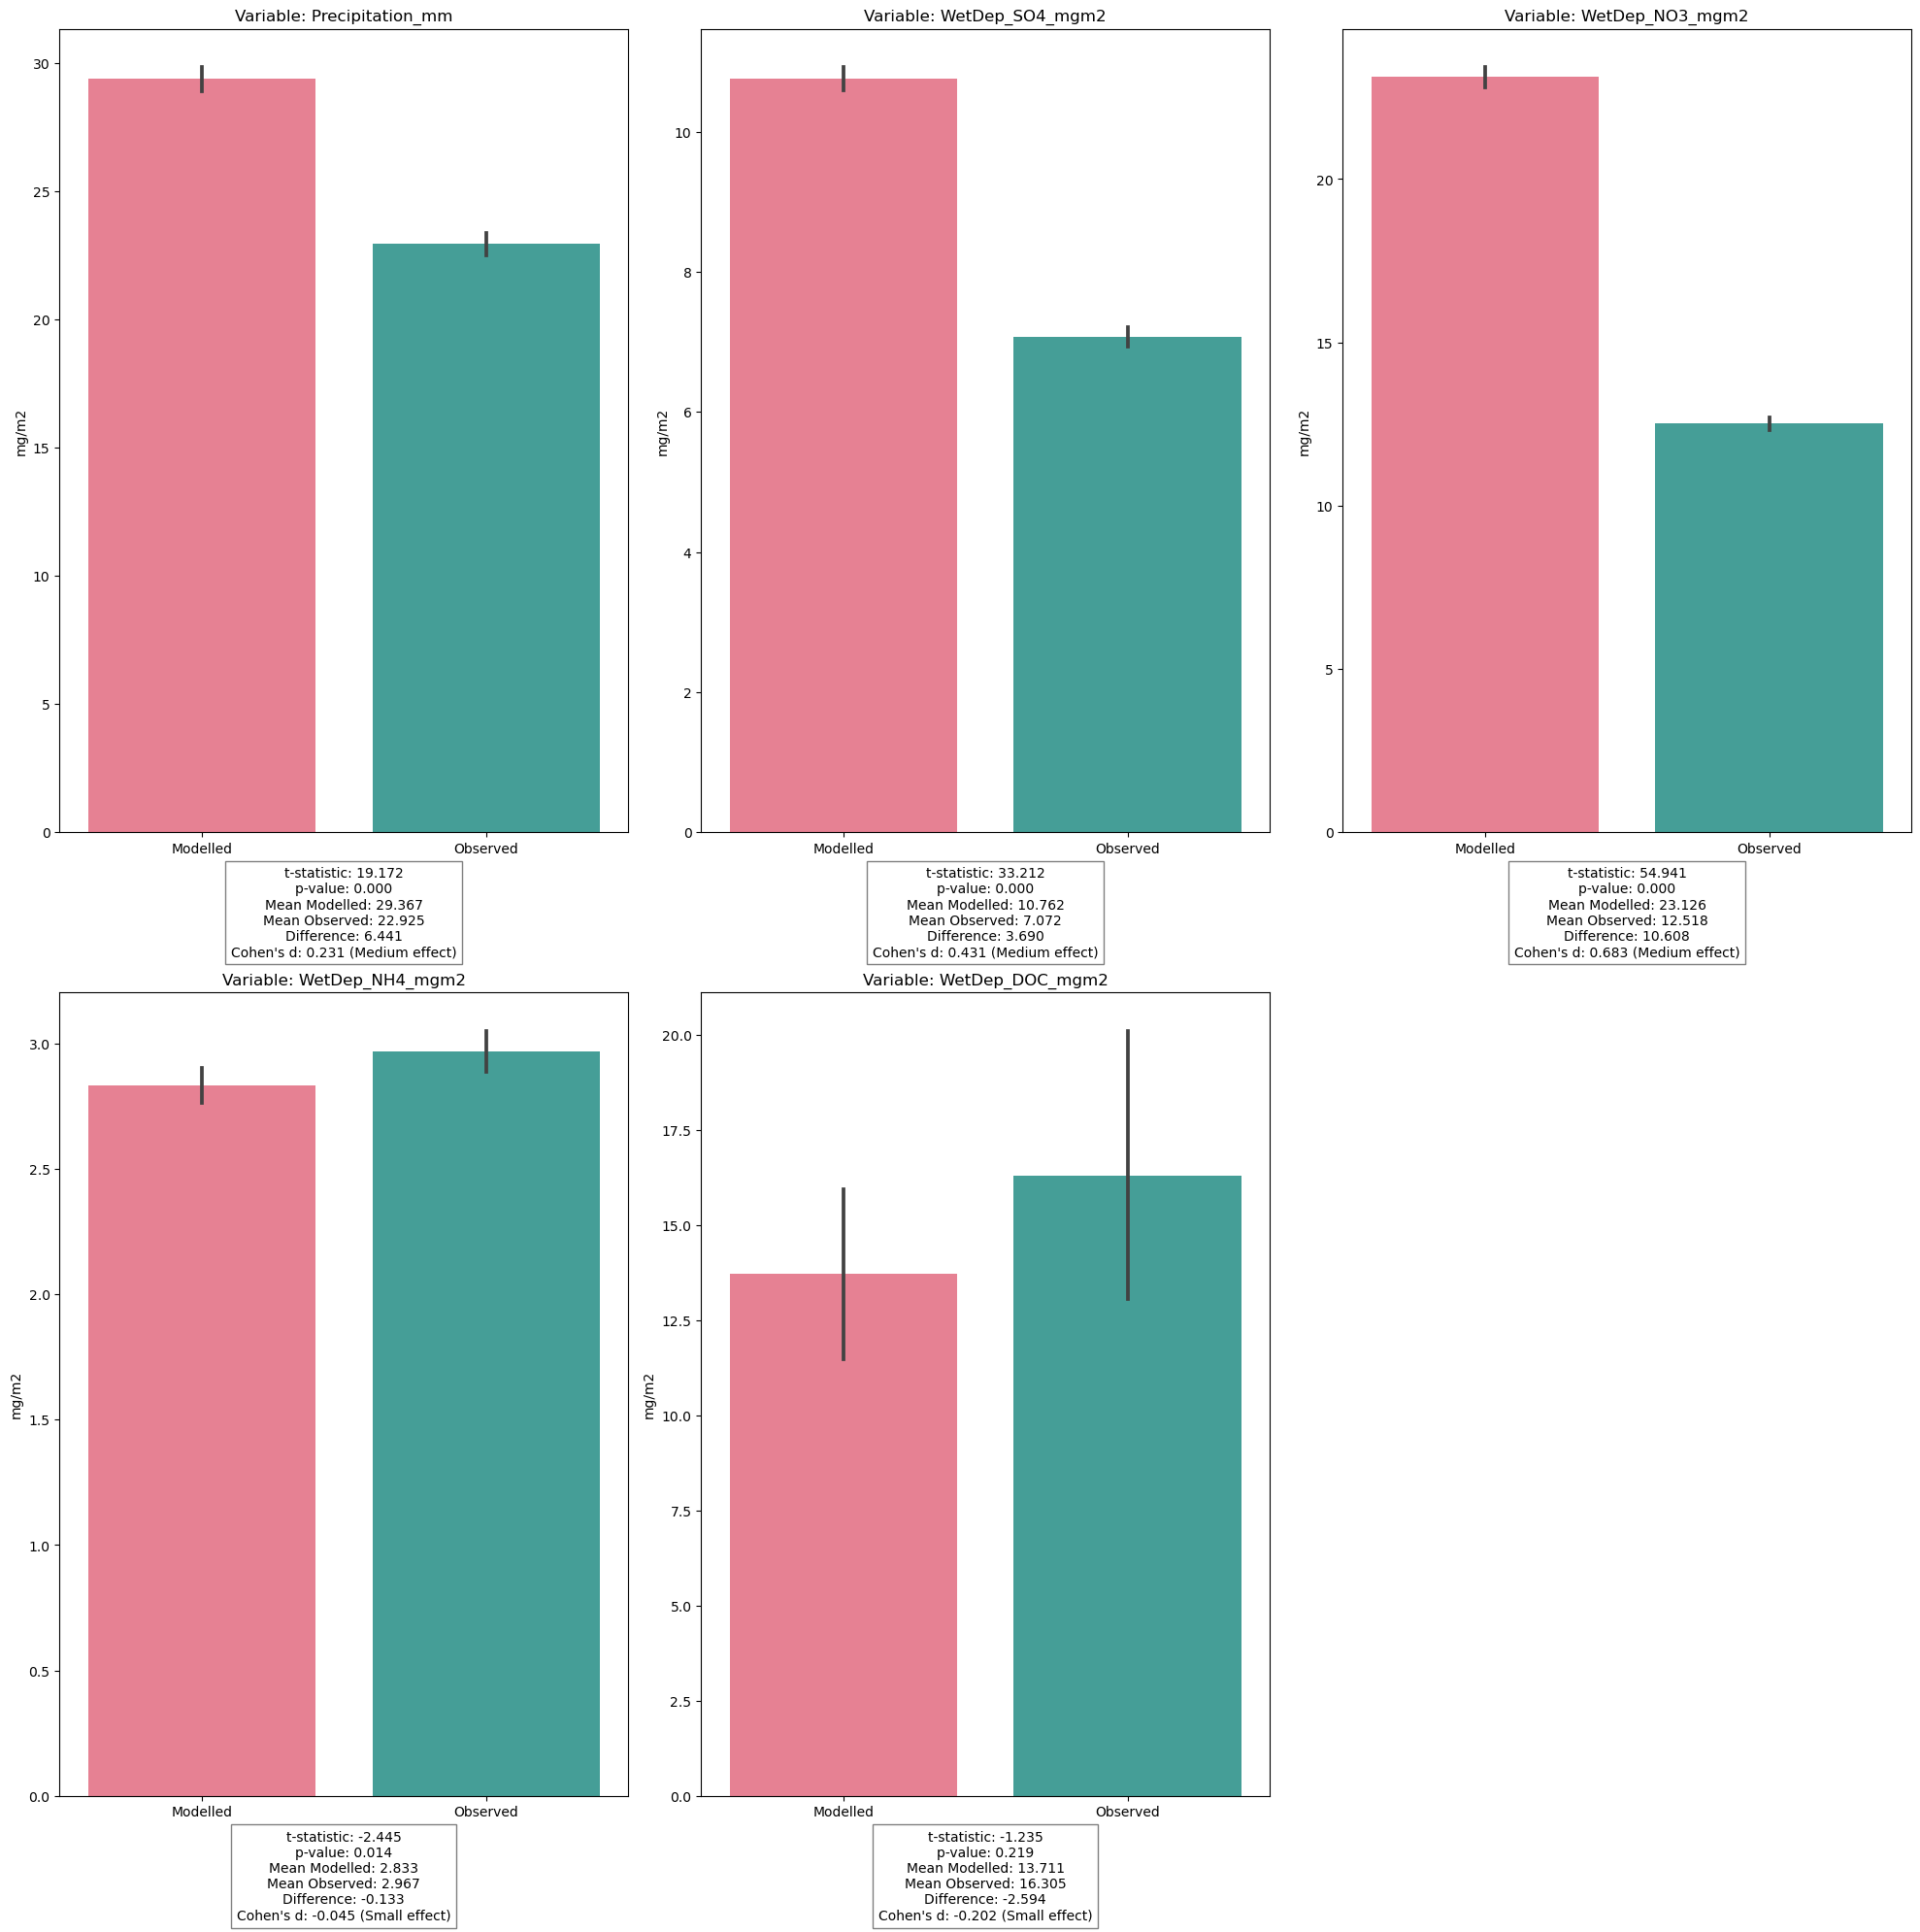

In [22]:
#Run a ttest on modeled vs. observed for each variable
warnings.filterwarnings("ignore") # Suppress specific warning types

num_cols = 3
num_rows = 2

# Create the figure and axes for the grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 20))
axes = axes.flatten()

# Iterate through each unique variable
for idx, i in enumerate(mod_nadp_clean_100_chem['Variable'].unique()):
    # Filter the data for the current variable
    df = mod_nadp_clean_100_chem.loc[mod_nadp_clean_100_chem['Variable'] == i]

    # Melt the DataFrame to long format
    df_long = pd.melt(df, id_vars=['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'lat', 'lon', 'Precip_Percent_Error', 'Percent_Error', 'Variable'],
                      value_vars=['Modelled', 'Observed'], var_name='Measurement')

    # Perform the t-test
    modelled = df_long[df_long['Measurement'] == 'Modelled']['value'].dropna()
    observed = df_long[df_long['Measurement'] == 'Observed']['value'].dropna()
    t_stat, p_value = ttest_ind(modelled, observed, equal_var=False)  # Using Welch's t-test

    # Calculate the mean difference
    mean_modelled = modelled.mean()
    mean_observed = observed.mean()
    mean_difference = mean_modelled - mean_observed
    
    # Calculate Cohen's d
    cohens_d = calculate_cohens_d(modelled, observed)
    cohens_d_interpretation = interpret_cohens_d(cohens_d)

    # Plot the barplot
    ax = axes[idx]
    sns.barplot(data=df_long, x='Measurement', y='value', palette='husl', ax=ax)
    ax.set_title(f'Variable: {i}')
    ax.set_ylabel('mg/m2')
    ax.set_xlabel('')
    
    # Add text for the statistics
    stats_text = (f"t-statistic: {t_stat:.3f}\np-value: {p_value:.3f}\n"
                  f"Mean Modelled: {mean_modelled:.3f}\nMean Observed: {mean_observed:.3f}\n"
                  f"Difference: {mean_difference:.3f}\nCohen's d: {cohens_d:.3f} ({cohens_d_interpretation})")
    ax.text(0.5, -0.1, stats_text, ha='center', va='center', transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
    
    # Adjust layout to avoid overlap
    plt.tight_layout()

# Hide any unused subplots
for idx in range(len(mod_nadp_clean_100_chem['Variable'].unique()), num_rows * num_cols):
    fig.delaxes(axes[idx])

# Show the plot (and optionally save it)
plt.show()


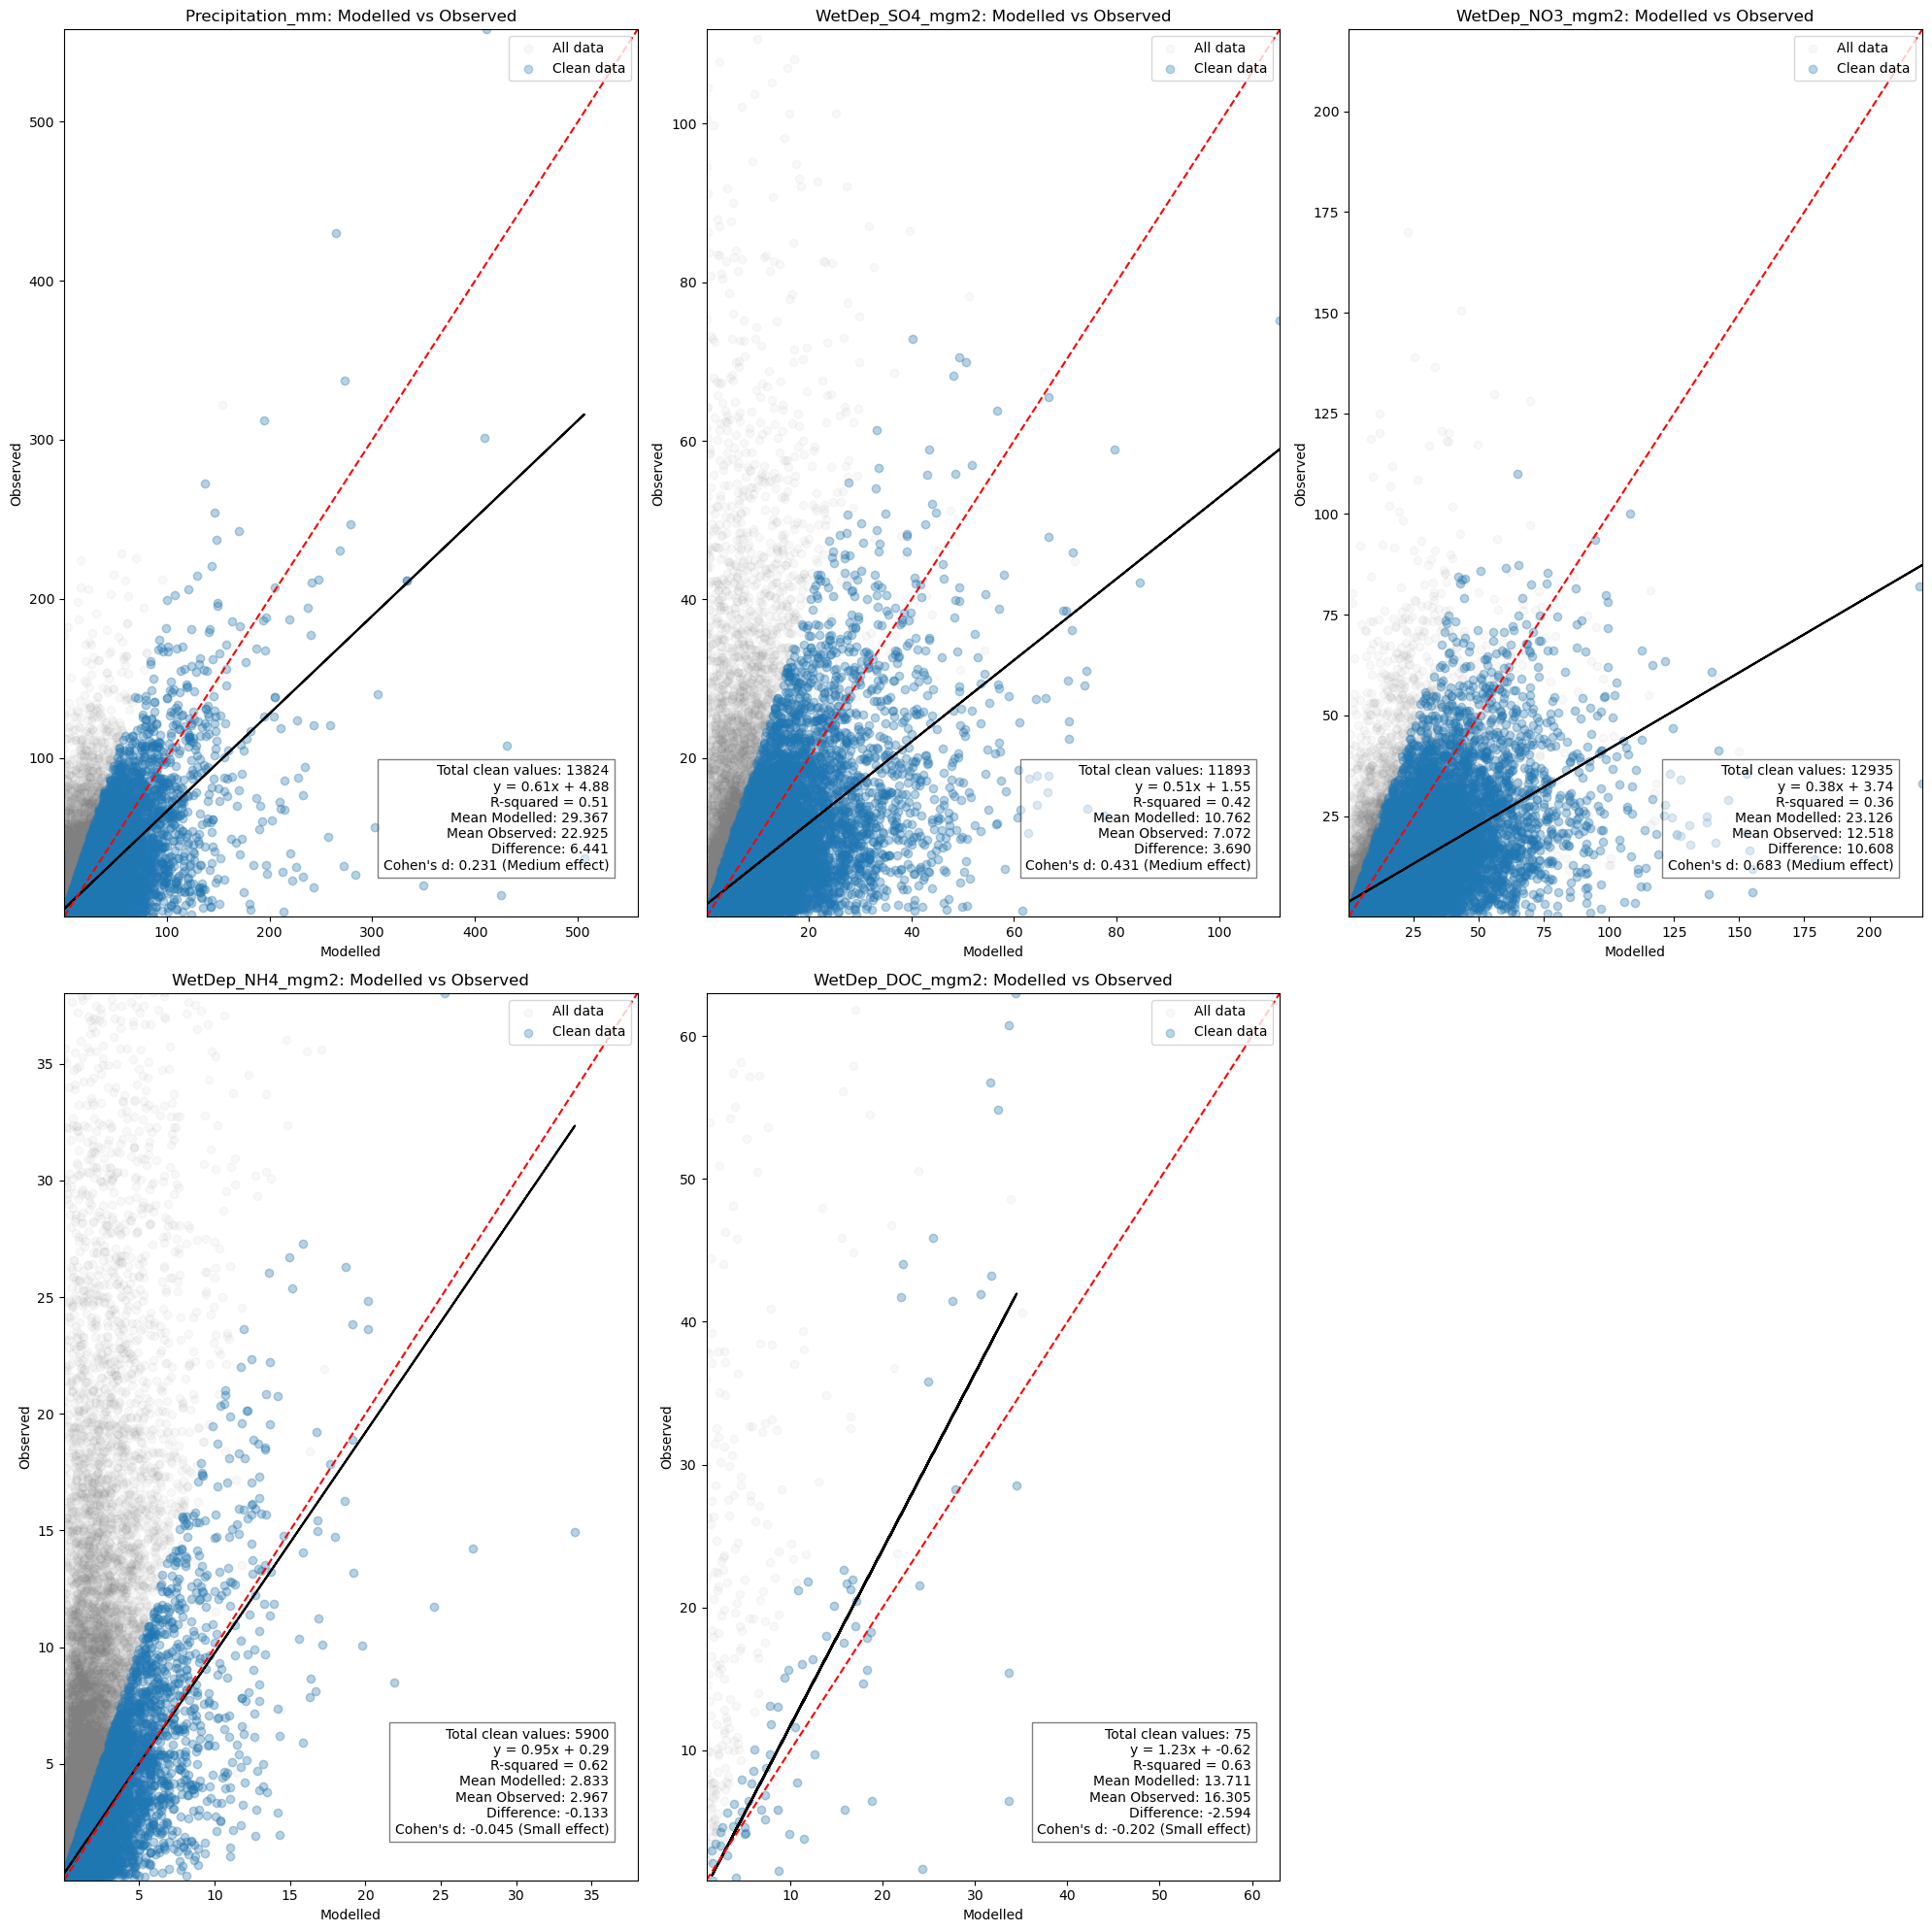

In [23]:
#Run a regression and scatter plot for observed vs. modelled

# Number of columns and rows for the grid
num_cols = 3
num_rows = 2

# Create the figure and axes for the grid
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 20))
axes = axes.flatten()

# Iterate through each unique variable
for idx, i in enumerate(mod_nadp_clean_100_chem['Variable'].unique()):
    
    # Filter the data for the current variable
    df = mod_nadp_clean_100_chem.loc[mod_nadp_clean_100_chem['Variable'] == i]
    df_full = mod_nadp_clean.loc[mod_nadp_clean['Variable'] == i]
    
    # Calculate min and max values for axis limits
    min_val = min(df['Modelled'].min(), df['Observed'].min())
    max_val = max(df['Modelled'].max(), df['Observed'].max())

    # Calculate the regression statistics
    slope, intercept, r_value, p_value, std_err = linregress(df['Modelled'], df['Observed'])

    # Calculate total number of observations and mean per site
    total_observations = len(df)
    mean_per_site = df.groupby('siteId').size().mean()
    # Perform the t-test
    # Melt the DataFrame to long format
    df_long = pd.melt(df, id_vars=['siteId', 'SamplingInt', 'dateOnround', 'dateOffround', 'lat', 'lon', 'Precip_Percent_Error', 'Percent_Error', 'Variable'],
                      value_vars=['Modelled', 'Observed'], var_name='Measurement')

    modelled = df_long[df_long['Measurement'] == 'Modelled']['value'].dropna()
    observed = df_long[df_long['Measurement'] == 'Observed']['value'].dropna()
    t_stat, p_value = ttest_ind(modelled, observed, equal_var=False)  # Using Welch's t-test

    # Calculate the mean difference
    mean_modelled = modelled.mean()
    mean_observed = observed.mean()
    mean_difference = mean_modelled - mean_observed

    # Calculate Cohen's d
    cohens_d = calculate_cohens_d(modelled, observed)
    cohens_d_interpretation = interpret_cohens_d(cohens_d)

    # Plot scatter plot
    ax = axes[idx]
    
    # Plot points from the full dataset in very transparent grey
    ax.scatter(df_full['Modelled'], df_full['Observed'], color='grey', alpha=0.05, label='All data')

    #Plot cleaned data
    ax.scatter(df['Modelled'], df['Observed'], alpha=0.3, label = 'Clean data')
    ax.set_title(f'{i}: Modelled vs Observed')
    ax.set_xlabel('Modelled')
    ax.set_ylabel('Observed')
    ax.set_xlim(min_val, max_val)  # Set the same limits for x-axis and y-axis
    ax.set_ylim(min_val, max_val)
    ax.legend(loc = 'upper right')
    
    # Plotting the linear regression line
    ax.plot(df['Modelled'], slope * df['Modelled'] + intercept, color='black')

    # Add the regression equation, R-squared value, and p-value to the plot
    equation = f'y = {slope:.2f}x + {intercept:.2f}'
    r_squared = f'R-squared = {r_value**2:.2f}'
    p_val = f'p-value = {p_value:.2e}'
    stats_text = (f'Total clean values: {total_observations}\n'
                  f'{equation}\n{r_squared}\n'
                  #f"t-statistic: {t_stat:.3f}\np-value: {p_value:.3f}\n"
                  f"Mean Modelled: {mean_modelled:.3f}\nMean Observed: {mean_observed:.3f}\n"
                  f"Difference: {mean_difference:.3f}\nCohen's d: {cohens_d:.3f} ({cohens_d_interpretation})")
    ax.text(0.95, 0.05, stats_text, ha='right', va='bottom', transform=ax.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

    # Add identity line (y=x)
    abline(1, 0, ax=ax, linestyle='--', color='red')

# Hide any unused subplots
for idx in range(len(mod_nadp_clean_100_chem['Variable'].unique()), num_rows * num_cols):
    fig.delaxes(axes[idx])

# Adjust layout to avoid overlap
plt.tight_layout()


# Show the plot (and optionally save it)
plt.show()
